# 11 - Reservation Objective Sweeps

This notebook looks for situations where strict Class 1 reservation does better than pooled FCFS.

The sweep is centered on the current demand baseline: about 25 arrivals per day for each class, so about 50 total arrivals per day, and 32 appointment slots per day in this notebook. For each scenario and seed, FCFS is run once. Then strict reservation is run for different `Q` values and compared to that matched FCFS run.

The main capacity objective is booked-slot utilization: booked appointment slots on service days divided by available slots. This is the right utilization measure when we want to see whether protected slots are left empty.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable=None, **kwargs):
        return iterable


def find_repo_dir(start: Path) -> Path:
    current = Path(start).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "simulation" / "engine.py").exists() and (
            candidate / "analysis" / "metrics.py"
        ).exists():
            return candidate
    raise FileNotFoundError("Could not find the repository root from the current notebook location.")


REPO_DIR = find_repo_dir(Path.cwd())
if str(REPO_DIR) not in sys.path:
    sys.path.insert(0, str(REPO_DIR))

from analysis.metrics import aggregate_result_row, class_result_rows
from simulation.engine import ClinicAppointmentSimulation
from simulation.model import PatientClassParams, SimulationConfig, ThresholdRule

plt.style.use("default")

## Sweep Settings

`Q` means protected Class 1 slots per day. FCFS always has `Q = 0`. Here the demand grid keeps both classes at the same arrival rate and uses four values: $\lambda_1=\lambda_2 \in \{20,25,35,50\}$ arrivals per day.


In [2]:
Q_VALUES = [0, 4, 8, 12, 16, 20, 24, 28, 32]
EQUAL_CLASS_ARRIVAL_VALUES = [20, 25, 35, 50]
SEEDS = list(range(5101, 5106))

BASELINE_CLASS_ARRIVAL_RATE = 25.0
BASELINE_TOTAL_DEMAND = 2 * BASELINE_CLASS_ARRIVAL_RATE

CLASS_1_WEIGHTS = [1.0, 1.25, 1.5, 2.0, 3.0]
CLASS_2_WEIGHT = 1.0
SLOT_COSTS = [0.0, 0.02, 0.05, 0.10]
WAIT_PENALTIES = [0.0, 0.02, 0.05, 0.10]

UTILIZATION_FLOORS = [0.50, 0.75, 0.85, 0.90]
SERVED_RATE_FLOORS = [0.45, 0.55, 0.65, 0.70]
CLASS_UTILIZATION_GAP_LIMITS = [0.10, 0.20, 0.30]

MAIN_CLASS_1_WEIGHT = 1.5
MAIN_SLOT_COST = 0.05
MAIN_WAIT_PENALTY = 0.05
MAIN_NET_WAIT_PENALTY = 0.0
MAIN_UTILIZATION_FLOOR = 0.85
MAIN_SERVED_RATE_FLOOR = 0.55
MAIN_CLASS_UTILIZATION_GAP_LIMIT = 0.20

BASE_CONFIG = {
    "slots_per_day": 32,
    "horizon_days": 14,
    "burn_in_days": 30,
    "measure_days": 365,
    "cooldown_days": 10,
    "reserved_class_id": 1,
}

pd.Series(
    {
        "q_values": Q_VALUES,
        "equal_class_arrival_values": EQUAL_CLASS_ARRIVAL_VALUES,
        "baseline_class_arrival_rate": BASELINE_CLASS_ARRIVAL_RATE,
        "baseline_total_demand": BASELINE_TOTAL_DEMAND,
        "seeds": f"{SEEDS[0]}-{SEEDS[-1]}",
        "class_1_weights": CLASS_1_WEIGHTS,
        "slot_costs": SLOT_COSTS,
        "wait_penalties": WAIT_PENALTIES,
        "utilization_floors": UTILIZATION_FLOORS,
        "served_rate_floors": SERVED_RATE_FLOORS,
        "class_utilization_gap_limits": CLASS_UTILIZATION_GAP_LIMITS,
        "main_class_1_weight": MAIN_CLASS_1_WEIGHT,
        "main_slot_cost": MAIN_SLOT_COST,
        "main_wait_penalty": MAIN_WAIT_PENALTY,
        "main_utilization_floor": MAIN_UTILIZATION_FLOOR,
        "main_served_rate_floor": MAIN_SERVED_RATE_FLOOR,
        "main_class_utilization_gap_limit": MAIN_CLASS_UTILIZATION_GAP_LIMIT,
        "slots_per_day": BASE_CONFIG["slots_per_day"],
        "horizon_days": BASE_CONFIG["horizon_days"],
    },
    name="value",
).to_frame()


,value
q_values,"[0, 4, 8, 12, 16, 20, 24, 28, 32]"
equal_class_arrival_values,"[20, 25, 35, 50]"
baseline_class_arrival_rate,25.0
baseline_total_demand,50.0
seeds,5101-5105
class_1_weights,"[1.0, 1.25, 1.5, 2.0, 3.0]"
slot_costs,"[0.0, 0.02, 0.05, 0.1]"
wait_penalties,"[0.0, 0.02, 0.05, 0.1]"
utilization_floors,"[0.5, 0.75, 0.85, 0.9]"
served_rate_floors,"[0.45, 0.55, 0.65, 0.7]"


## Behavior Regimes

The grid changes two things: the equal arrival rate used for both classes, and whether Class 1 has better, equal, or worse booking behavior than Class 2. The advantaged case follows the realistic configuration most closely; the other cases help check whether the same answer still holds when the two classes behave differently.


In [3]:
SCENARIO_TYPES = {
    "symmetric_baseline": {
        1: {
            "cancel_prob": 0.015,
            "balk_prob": {"threshold": 17, "low": 0.03, "high": 0.63},
            "no_show_prob": {"threshold": 17, "low": 0.08, "high": 0.41},
        },
        2: {
            "cancel_prob": 0.015,
            "balk_prob": {"threshold": 17, "low": 0.03, "high": 0.63},
            "no_show_prob": {"threshold": 17, "low": 0.08, "high": 0.41},
        },
    },
    "class_1_advantaged": {
        1: {
            "cancel_prob": 0.01,
            "balk_prob": {"threshold": 21, "low": 0.02, "high": 0.55},
            "no_show_prob": {"threshold": 21, "low": 0.01, "high": 0.31},
        },
        2: {
            "cancel_prob": 0.02,
            "balk_prob": {"threshold": 14, "low": 0.04, "high": 0.72},
            "no_show_prob": {"threshold": 14, "low": 0.15, "high": 0.51},
        },
    },
    "class_1_disadvantaged": {
        1: {
            "cancel_prob": 0.02,
            "balk_prob": {"threshold": 14, "low": 0.04, "high": 0.72},
            "no_show_prob": {"threshold": 14, "low": 0.15, "high": 0.51},
        },
        2: {
            "cancel_prob": 0.01,
            "balk_prob": {"threshold": 21, "low": 0.02, "high": 0.55},
            "no_show_prob": {"threshold": 21, "low": 0.01, "high": 0.31},
        },
    },
}


def make_scenario_grid() -> pd.DataFrame:
    rows = []
    for scenario_type in SCENARIO_TYPES:
        for class_arrival_rate in EQUAL_CLASS_ARRIVAL_VALUES:
            rows.append(
                {
                    "scenario_id": f"{scenario_type}|lambda1=lambda2={class_arrival_rate}",
                    "scenario_type": scenario_type,
                    "class_arrival_rate": float(class_arrival_rate),
                    "lambda_total": float(2 * class_arrival_rate),
                    "class_1_share": 0.50,
                    "lambda_1": float(class_arrival_rate),
                    "lambda_2": float(class_arrival_rate),
                }
            )
    return pd.DataFrame(rows)


scenario_grid = make_scenario_grid()
scenario_grid


,scenario_id,scenario_type,class_arrival_rate,lambda_total,class_1_share,lambda_1,lambda_2
0,symmetric_baseline|lambda1=lambda2=20,symmetric_baseline,20.0,40.0,0.5,20.0,20.0
1,symmetric_baseline|lambda1=lambda2=25,symmetric_baseline,25.0,50.0,0.5,25.0,25.0
2,symmetric_baseline|lambda1=lambda2=35,symmetric_baseline,35.0,70.0,0.5,35.0,35.0
3,symmetric_baseline|lambda1=lambda2=50,symmetric_baseline,50.0,100.0,0.5,50.0,50.0
4,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,20.0,20.0
5,class_1_advantaged|lambda1=lambda2=25,class_1_advantaged,25.0,50.0,0.5,25.0,25.0
6,class_1_advantaged|lambda1=lambda2=35,class_1_advantaged,35.0,70.0,0.5,35.0,35.0
7,class_1_advantaged|lambda1=lambda2=50,class_1_advantaged,50.0,100.0,0.5,50.0,50.0
8,class_1_disadvantaged|lambda1=lambda2=20,class_1_disadvantaged,20.0,40.0,0.5,20.0,20.0
9,class_1_disadvantaged|lambda1=lambda2=25,class_1_disadvantaged,25.0,50.0,0.5,25.0,25.0


## Simulation Helpers

In [4]:
def safe_divide(numerator: float, denominator: float) -> float:
    return numerator / denominator if denominator else 0.0


def build_config(scenario: pd.Series, *, q: int, seed: int | None) -> SimulationConfig:
    behavior = SCENARIO_TYPES[scenario["scenario_type"]]
    classes = {}
    for class_id, lambda_value in [(1, scenario["lambda_1"]), (2, scenario["lambda_2"])]:
        params = behavior[class_id]
        classes[class_id] = PatientClassParams(
            class_id=class_id,
            lambda_per_day=float(lambda_value),
            balk_prob=ThresholdRule(**params["balk_prob"]),
            cancel_prob=float(params["cancel_prob"]),
            no_show_prob=ThresholdRule(**params["no_show_prob"]),
            value=1.0,
        )

    return SimulationConfig(
        slots_per_day=BASE_CONFIG["slots_per_day"],
        horizon_days=BASE_CONFIG["horizon_days"],
        burn_in_days=BASE_CONFIG["burn_in_days"],
        measure_days=BASE_CONFIG["measure_days"],
        cooldown_days=BASE_CONFIG["cooldown_days"],
        classes=classes,
        seed=seed,
        reserved_class_id=BASE_CONFIG["reserved_class_id"] if q > 0 else None,
        reserved_slots_per_day=int(q),
    )


def result_summary_row(result, config: SimulationConfig, fixed_values: dict) -> dict:
    aggregate = aggregate_result_row(result, fixed_values)
    class_df = pd.DataFrame(class_result_rows(result, fixed_values)).set_index("class_id")
    c1 = class_df.loc[1]
    c2 = class_df.loc[2]
    total_arrivals = aggregate["total_arrivals"]

    return {
        **fixed_values,
        "slots_per_day": config.slots_per_day,
        "horizon_days": config.horizon_days,
        "total_arrivals": total_arrivals,
        "total_served": aggregate["total_served"],
        "total_offered": aggregate["total_offered"],
        "total_booked_slots": aggregate["total_booked_slots"],
        "total_served_slots": aggregate["total_served_slots"],
        "total_no_show_slots": aggregate["total_no_show_slots"],
        "served_rate": safe_divide(aggregate["total_served"], total_arrivals),
        "average_utilization": aggregate["average_utilization"],
        "booked_slot_utilization": aggregate["booked_slot_utilization"],
        "mean_offered_booking_delay": aggregate["mean_offered_booking_delay"],
        "total_balked": aggregate["total_balked"],
        "total_no_offer": aggregate["total_no_offer"],
        "total_canceled": aggregate["total_canceled"],
        "total_no_show": aggregate["total_no_show"],
        "total_unresolved_booked": aggregate["total_unresolved_booked"],
        "class_1_arrivals": c1["arrivals"],
        "class_2_arrivals": c2["arrivals"],
        "class_1_served": c1["served"],
        "class_2_served": c2["served"],
        "class_1_no_show": c1["no_show"],
        "class_2_no_show": c2["no_show"],
        "class_1_offered": c1["offered"],
        "class_2_offered": c2["offered"],
        "class_1_served_rate": c1["percent_serviced"],
        "class_2_served_rate": c2["percent_serviced"],
        "min_class_served_rate": min(c1["percent_serviced"], c2["percent_serviced"]),
        "class_1_slot_utilization": c1["slot_utilization"],
        "class_2_slot_utilization": c2["slot_utilization"],
        "class_utilization_gap": abs(c1["slot_utilization"] - c2["slot_utilization"]),
        "class_1_booked_slot_utilization": c1["booked_slot_utilization"],
        "class_2_booked_slot_utilization": c2["booked_slot_utilization"],
        "class_booked_slot_utilization_gap": abs(c1["booked_slot_utilization"] - c2["booked_slot_utilization"]),
        "class_1_total_offered_delay": c1["total_offered_booking_delay"],
        "class_2_total_offered_delay": c2["total_offered_booking_delay"],
    }


def validate_accounting(run_df: pd.DataFrame, tol: float = 1e-9) -> None:
    partition = (
        run_df["total_served"]
        + run_df["total_balked"]
        + run_df["total_no_offer"]
        + run_df["total_canceled"]
        + run_df["total_no_show"]
        + run_df["total_unresolved_booked"]
    )
    if (partition - run_df["total_arrivals"]).abs().max() > tol:
        raise AssertionError("Outcomes do not partition arrivals.")


def run_policy_grid(scenarios: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, scenario in tqdm(list(scenarios.iterrows()), desc="scenario"):
        scenario_metadata = scenario.to_dict()

        for seed in SEEDS:
            fcfs_config = build_config(scenario, q=0, seed=int(seed))
            fcfs_result = ClinicAppointmentSimulation(fcfs_config).run()
            fixed = {**scenario_metadata, "policy": "Pooled FCFS", "seed": int(seed), "Q": 0}
            rows.append(result_summary_row(fcfs_result, fcfs_config, fixed))

            for q in Q_VALUES:
                strict_config = build_config(scenario, q=int(q), seed=int(seed))
                strict_result = ClinicAppointmentSimulation(strict_config).run()
                fixed = {**scenario_metadata, "policy": "Strict C1 reservation", "seed": int(seed), "Q": int(q)}
                rows.append(result_summary_row(strict_result, strict_config, fixed))

    run_df = pd.DataFrame(rows)
    validate_accounting(run_df)
    return run_df


## Objective Helpers

For every scenario, seed, and strict-reservation value $Q$, this notebook computes the same scoring rules as notebook 10. The main number is the difference from FCFS:

$$
\Delta U(Q; a, j) = U_{strict}(Q; a, j) - U_{FCFS}(a, j),
$$

Here $a$ is the scenario and $j$ is the seed. The TeX reference files use $r$ for residual delay, so this notebook does not use $r$ as a seed index in the formulas. For this notebook, booked-slot utilization is:

$$
\rho^{\mathrm{booked}}
=
\frac{\mathrm{booked\ slots\ on\ service\ days}}{S\times\mathrm{measured\ days}}.
$$

A protected slot that is not booked lowers this value. A no-show still counts as booked because the slot was occupied on the schedule.

For each setting, the notebook averages the strict-minus-FCFS difference across seeds:

$$
\bar\Delta U(Q) = \frac{1}{J}\sum_{j=1}^{J}\Delta U(Q; a, j),
\qquad
\text{95\% range}=\bar\Delta U \pm 1.96\frac{\sigma_{\Delta}}{\sqrt{J}}.
$$

The labels mean:

$$
\text{win}: \bar\Delta U>0 \text{ and the lower end of the 95\% range is above 0},
$$

$$
\text{possible win}: \bar\Delta U>0 \text{ but the 95\% range still includes 0},
$$

$$
\text{loss}: \bar\Delta U\le 0.
$$

The best $Q$ is the one with the highest average difference from FCFS:

$$
Q^*(a) = \arg\max_Q \bar\Delta U(Q; a).
$$


In [5]:
def weighted_mean_offered_delay(row: pd.Series, class_1_weight: float, class_2_weight: float = CLASS_2_WEIGHT) -> float:
    weighted_delay = (
        class_1_weight * row["class_1_total_offered_delay"]
        + class_2_weight * row["class_2_total_offered_delay"]
    )
    weighted_offered = (
        class_1_weight * row["class_1_offered"]
        + class_2_weight * row["class_2_offered"]
    )
    return safe_divide(weighted_delay, weighted_offered)


def score_rows_for_run(row: pd.Series) -> list[dict]:
    rows = []
    q_share = safe_divide(row["Q"], row["slots_per_day"])

    rows.append({**row.to_dict(), "score_name": "served_rate", "class_1_weight": 1.0, "slot_cost": 0.0, "wait_penalty": 0.0, "score_value": row["served_rate"]})
    rows.append({**row.to_dict(), "score_name": "booked_slot_utilization", "class_1_weight": 1.0, "slot_cost": 0.0, "wait_penalty": 0.0, "score_value": row["booked_slot_utilization"]})

    for weight in CLASS_1_WEIGHTS:
        weighted_served_rate = safe_divide(
            weight * row["class_1_served"] + CLASS_2_WEIGHT * row["class_2_served"],
            weight * row["class_1_arrivals"] + CLASS_2_WEIGHT * row["class_2_arrivals"],
        )
        weighted_attended_slot_score = weight * row["class_1_slot_utilization"] + CLASS_2_WEIGHT * row["class_2_slot_utilization"]
        weighted_booked_slot_score = weight * row["class_1_booked_slot_utilization"] + CLASS_2_WEIGHT * row["class_2_booked_slot_utilization"]
        weighted_delay = weighted_mean_offered_delay(row, weight)

        rows.append({**row.to_dict(), "score_name": "weighted_served_rate", "class_1_weight": weight, "slot_cost": 0.0, "wait_penalty": 0.0, "score_value": weighted_served_rate})
        rows.append({**row.to_dict(), "score_name": "weighted_attended_slot_score", "class_1_weight": weight, "slot_cost": 0.0, "wait_penalty": 0.0, "score_value": weighted_attended_slot_score})
        rows.append({**row.to_dict(), "score_name": "weighted_booked_slot_score", "class_1_weight": weight, "slot_cost": 0.0, "wait_penalty": 0.0, "score_value": weighted_booked_slot_score})

        for slot_cost in SLOT_COSTS:
            rows.append({**row.to_dict(), "score_name": "net_priority_score", "class_1_weight": weight, "slot_cost": slot_cost, "wait_penalty": 0.0, "score_value": weighted_served_rate - slot_cost * q_share})
            rows.append({**row.to_dict(), "score_name": "net_booked_slot_score", "class_1_weight": weight, "slot_cost": slot_cost, "wait_penalty": 0.0, "score_value": weighted_booked_slot_score - slot_cost * q_share})

            for wait_penalty in WAIT_PENALTIES:
                delay_cost = wait_penalty * safe_divide(weighted_delay, row["horizon_days"])
                rows.append({**row.to_dict(), "score_name": "wait_adjusted_booked_slot_score", "class_1_weight": weight, "slot_cost": slot_cost, "wait_penalty": wait_penalty, "score_value": weighted_booked_slot_score - slot_cost * q_share - delay_cost})

    return rows


def rule_rows_for_run(row: pd.Series) -> list[dict]:
    rows = []
    for utilization_floor in UTILIZATION_FLOORS:
        for served_floor in SERVED_RATE_FLOORS:
            for gap_limit in CLASS_UTILIZATION_GAP_LIMITS:
                passes_rules = (
                    row["booked_slot_utilization"] >= utilization_floor
                    and row["min_class_served_rate"] >= served_floor
                    and row["class_booked_slot_utilization_gap"] <= gap_limit
                )
                rows.append(
                    {
                        **row.to_dict(),
                        "utilization_floor": utilization_floor,
                        "served_rate_floor": served_floor,
                        "class_utilization_gap_limit": gap_limit,
                        "passes_rules": passes_rules,
                        "utilization_if_rules_pass": row["booked_slot_utilization"] if passes_rules else np.nan,
                        "wait_score_if_rules_pass": -row["mean_offered_booking_delay"] if passes_rules else np.nan,
                    }
                )
    return rows


def expand_scores(run_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    score_df = pd.DataFrame([objective for _, row in run_df.iterrows() for objective in score_rows_for_run(row)])
    rule_df = pd.DataFrame([constraint for _, row in run_df.iterrows() for constraint in rule_rows_for_run(row)])
    return score_df, rule_df


## Run The Sweep

This is the slow cell. It runs 12 scenarios, 5 seeds, one FCFS baseline per scenario/seed, and strict reservation for every configured `Q`.


In [6]:
run_df = run_policy_grid(scenario_grid)
score_df, rule_df = expand_scores(run_df)

print(f"Simulation rows: {len(run_df):,}")
print(f"Score rows: {len(score_df):,}")
print(f"Rule-check rows: {len(rule_df):,}")

scenario:   0%|          | 0/12 [00:00<?, ?it/s]

Simulation rows: 600
Score rows: 82,200
Rule-check rows: 28,800


## Checks

These checks make sure the comparisons are valid before making tables and plots.


In [7]:
assert (run_df.loc[run_df["policy"] == "Pooled FCFS", "Q"] == 0).all(), "FCFS must have Q = 0."

booked_scores = score_df[score_df["score_name"] == "booked_slot_utilization"]
assert booked_scores["score_value"].between(0, 1).all(), "Booked-slot utilization must be in [0, 1]."

weighted_served = score_df[score_df["score_name"] == "weighted_served_rate"]
assert weighted_served["score_value"].between(0, 1).all(), "Weighted served score must be in [0, 1]."

for score_name in ["net_priority_score", "net_booked_slot_score"]:
    net = score_df[score_df["score_name"] == score_name].sort_values("slot_cost")
    monotone = net.groupby(["scenario_id", "policy", "seed", "Q", "class_1_weight"])["score_value"].apply(lambda s: s.diff().dropna().le(1e-12).all())
    assert monotone.all(), f"Higher slot-cost penalties should not increase {score_name}."

fcfs_by_cost = score_df[score_df["policy"] == "Pooled FCFS"].groupby(["scenario_id", "score_name", "seed", "class_1_weight", "wait_penalty"])
for _, group in fcfs_by_cost:
    if group["slot_cost"].nunique() > 1:
        assert group["score_value"].nunique() == 1, "FCFS score should not change with slot cost because Q = 0."

validate_accounting(run_df)
print("Sweep assertions passed.")


Sweep assertions passed.


## Compare Strict Reservation To FCFS

This section lines up every strict-reservation run with the FCFS run from the same scenario and seed, then computes the difference.


In [8]:
PAIR_KEYS = [
    "scenario_id",
    "scenario_type",
    "class_arrival_rate",
    "lambda_total",
    "class_1_share",
    "lambda_1",
    "lambda_2",
    "seed",
    "score_name",
    "class_1_weight",
    "slot_cost",
    "wait_penalty",
]

strict_objectives = score_df[score_df["policy"] == "Strict C1 reservation"].copy()
fcfs_objectives = score_df[score_df["policy"] == "Pooled FCFS"].copy()
fcfs_objectives = fcfs_objectives[PAIR_KEYS + ["score_value"]].rename(columns={"score_value": "fcfs_score_value"})

paired_objectives = strict_objectives.merge(fcfs_objectives, on=PAIR_KEYS, how="left")
assert paired_objectives["fcfs_score_value"].notna().all(), "Score rows have missing FCFS matches."
paired_objectives["difference_vs_fcfs"] = paired_objectives["score_value"] - paired_objectives["fcfs_score_value"]

paired_objectives.head()

,scenario_id,scenario_type,class_arrival_rate,lambda_total,class_1_share,lambda_1,lambda_2,policy,seed,Q,...,class_booked_slot_utilization_gap,class_1_total_offered_delay,class_2_total_offered_delay,score_name,class_1_weight,slot_cost,wait_penalty,score_value,fcfs_score_value,difference_vs_fcfs
0,symmetric_baseline|lambda1=lambda2=20,symmetric_baseline,20.0,40.0,0.5,20.0,20.0,Strict C1 reservation,5101,0,...,0.000086,79172.0,79206.0,served_rate,1.0,0.0,0.0,0.750258,0.750258,0.0
1,symmetric_baseline|lambda1=lambda2=20,symmetric_baseline,20.0,40.0,0.5,20.0,20.0,Strict C1 reservation,5101,0,...,0.000086,79172.0,79206.0,booked_slot_utilization,1.0,0.0,0.0,1.000000,1.000000,0.0
2,symmetric_baseline|lambda1=lambda2=20,symmetric_baseline,20.0,40.0,0.5,20.0,20.0,Strict C1 reservation,5101,0,...,0.000086,79172.0,79206.0,weighted_served_rate,1.0,0.0,0.0,0.750258,0.750258,0.0
3,symmetric_baseline|lambda1=lambda2=20,symmetric_baseline,20.0,40.0,0.5,20.0,20.0,Strict C1 reservation,5101,0,...,0.000086,79172.0,79206.0,weighted_attended_slot_score,1.0,0.0,0.0,0.932363,0.932363,0.0
4,symmetric_baseline|lambda1=lambda2=20,symmetric_baseline,20.0,40.0,0.5,20.0,20.0,Strict C1 reservation,5101,0,...,0.000086,79172.0,79206.0,weighted_booked_slot_score,1.0,0.0,0.0,1.012072,1.012072,0.0


In [9]:
SUMMARY_KEYS = [
    "scenario_id",
    "scenario_type",
    "class_arrival_rate",
    "lambda_total",
    "class_1_share",
    "Q",
    "score_name",
    "class_1_weight",
    "slot_cost",
    "wait_penalty",
]

difference_summary = (
    paired_objectives.groupby(SUMMARY_KEYS)["difference_vs_fcfs"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
difference_summary["sem"] = difference_summary["std"].fillna(0.0) / np.sqrt(difference_summary["count"])
difference_summary["ci_low"] = difference_summary["mean"] - 1.96 * difference_summary["sem"]
difference_summary["ci_high"] = difference_summary["mean"] + 1.96 * difference_summary["sem"]
difference_summary["classification"] = np.select(
    [
        (difference_summary["mean"] > 0) & (difference_summary["ci_low"] > 0),
        difference_summary["mean"] > 0,
    ],
    ["win", "possible_win"],
    default="loss",
)

display(difference_summary.head())

,scenario_id,scenario_type,class_arrival_rate,lambda_total,class_1_share,Q,score_name,class_1_weight,slot_cost,wait_penalty,mean,std,count,sem,ci_low,ci_high,classification
0,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,booked_slot_utilization,1.0,0.00,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
1,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,net_booked_slot_score,1.0,0.00,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
2,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,net_booked_slot_score,1.0,0.02,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
3,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,net_booked_slot_score,1.0,0.05,0.0,0.0,0.0,5,0.0,0.0,0.0,loss
4,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,net_booked_slot_score,1.0,0.10,0.0,0.0,0.0,5,0.0,0.0,0.0,loss


## Summary Tables

These tables show the best `Q`, how often strict reservation wins, and the row-level differences from FCFS.


In [10]:
best_q = (
    difference_summary.sort_values("mean", ascending=False)
    .groupby(["scenario_id", "score_name", "class_1_weight", "slot_cost", "wait_penalty"], as_index=False)
    .head(1)
    .sort_values(["score_name", "scenario_type", "class_arrival_rate", "class_1_weight", "slot_cost", "wait_penalty"])
)

win_summary = (
    difference_summary.groupby(["scenario_type", "class_arrival_rate", "score_name", "class_1_weight", "slot_cost", "wait_penalty", "classification"])
    .size()
    .rename("num_q_values")
    .reset_index()
)

display(best_q.head(20))
display(win_summary.head(20))
display(paired_objectives[["scenario_id", "seed", "Q", "score_name", "class_1_weight", "slot_cost", "wait_penalty", "score_value", "fcfs_score_value", "difference_vs_fcfs"]].head(20))

,scenario_id,scenario_type,class_arrival_rate,lambda_total,class_1_share,Q,score_name,class_1_weight,slot_cost,wait_penalty,mean,std,count,sem,ci_low,ci_high,classification
0,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,booked_slot_utilization,1.00,0.00,0.0,0.000000,0.000000,5,0.000000,0.000000,0.000000,loss
1233,class_1_advantaged|lambda1=lambda2=25,class_1_advantaged,25.0,50.0,0.5,0,booked_slot_utilization,1.00,0.00,0.0,0.000000,0.000000,5,0.000000,0.000000,0.000000,loss
2466,class_1_advantaged|lambda1=lambda2=35,class_1_advantaged,35.0,70.0,0.5,0,booked_slot_utilization,1.00,0.00,0.0,0.000000,0.000000,5,0.000000,0.000000,0.000000,loss
3836,class_1_advantaged|lambda1=lambda2=50,class_1_advantaged,50.0,100.0,0.5,4,booked_slot_utilization,1.00,0.00,0.0,0.000000,0.000000,5,0.000000,0.000000,0.000000,loss
4932,class_1_disadvantaged|lambda1=lambda2=20,class_1_disadvantaged,20.0,40.0,0.5,0,booked_slot_utilization,1.00,0.00,0.0,0.000000,0.000000,5,0.000000,0.000000,0.000000,loss
6165,class_1_disadvantaged|lambda1=lambda2=25,class_1_disadvantaged,25.0,50.0,0.5,0,booked_slot_utilization,1.00,0.00,0.0,0.000000,0.000000,5,0.000000,0.000000,0.000000,loss
8357,class_1_disadvantaged|lambda1=lambda2=35,class_1_disadvantaged,35.0,70.0,0.5,28,booked_slot_utilization,1.00,0.00,0.0,0.000000,0.000000,5,0.000000,0.000000,0.000000,loss
9727,class_1_disadvantaged|lambda1=lambda2=50,class_1_disadvantaged,50.0,100.0,0.5,32,booked_slot_utilization,1.00,0.00,0.0,0.000000,0.000000,5,0.000000,0.000000,0.000000,loss
10412,symmetric_baseline|lambda1=lambda2=20,symmetric_baseline,20.0,40.0,0.5,16,booked_slot_utilization,1.00,0.00,0.0,0.000000,0.000000,5,0.000000,0.000000,0.000000,loss
11371,symmetric_baseline|lambda1=lambda2=25,symmetric_baseline,25.0,50.0,0.5,8,booked_slot_utilization,1.00,0.00,0.0,0.000000,0.000000,5,0.000000,0.000000,0.000000,loss


,scenario_type,class_arrival_rate,score_name,class_1_weight,slot_cost,wait_penalty,classification,num_q_values
0,class_1_advantaged,20.0,booked_slot_utilization,1.00,0.00,0.0,loss,9
1,class_1_advantaged,20.0,net_booked_slot_score,1.00,0.00,0.0,loss,6
2,class_1_advantaged,20.0,net_booked_slot_score,1.00,0.00,0.0,possible_win,2
3,class_1_advantaged,20.0,net_booked_slot_score,1.00,0.00,0.0,win,1
4,class_1_advantaged,20.0,net_booked_slot_score,1.00,0.02,0.0,loss,9
5,class_1_advantaged,20.0,net_booked_slot_score,1.00,0.05,0.0,loss,9
6,class_1_advantaged,20.0,net_booked_slot_score,1.00,0.10,0.0,loss,9
7,class_1_advantaged,20.0,net_booked_slot_score,1.25,0.00,0.0,loss,6
8,class_1_advantaged,20.0,net_booked_slot_score,1.25,0.00,0.0,possible_win,2
9,class_1_advantaged,20.0,net_booked_slot_score,1.25,0.00,0.0,win,1


,scenario_id,seed,Q,score_name,class_1_weight,slot_cost,wait_penalty,score_value,fcfs_score_value,difference_vs_fcfs
0,symmetric_baseline|lambda1=lambda2=20,5101,0,served_rate,1.0,0.00,0.00,0.750258,0.750258,0.0
1,symmetric_baseline|lambda1=lambda2=20,5101,0,booked_slot_utilization,1.0,0.00,0.00,1.000000,1.000000,0.0
2,symmetric_baseline|lambda1=lambda2=20,5101,0,weighted_served_rate,1.0,0.00,0.00,0.750258,0.750258,0.0
3,symmetric_baseline|lambda1=lambda2=20,5101,0,weighted_attended_slot_score,1.0,0.00,0.00,0.932363,0.932363,0.0
4,symmetric_baseline|lambda1=lambda2=20,5101,0,weighted_booked_slot_score,1.0,0.00,0.00,1.012072,1.012072,0.0
5,symmetric_baseline|lambda1=lambda2=20,5101,0,net_priority_score,1.0,0.00,0.00,0.750258,0.750258,0.0
6,symmetric_baseline|lambda1=lambda2=20,5101,0,net_booked_slot_score,1.0,0.00,0.00,1.012072,1.012072,0.0
7,symmetric_baseline|lambda1=lambda2=20,5101,0,wait_adjusted_booked_slot_score,1.0,0.00,0.00,1.012072,1.012072,0.0
8,symmetric_baseline|lambda1=lambda2=20,5101,0,wait_adjusted_booked_slot_score,1.0,0.00,0.02,0.996222,0.996222,0.0
9,symmetric_baseline|lambda1=lambda2=20,5101,0,wait_adjusted_booked_slot_score,1.0,0.00,0.05,0.972448,0.972448,0.0


## Constraint Tables

These tables use the meeting-note requirements: keep slot use above a chosen floor, keep the class slot-use gap below a chosen limit, and require each class to have a minimum served rate.


In [11]:
CONSTRAINT_PAIR_KEYS = [
    "scenario_id",
    "scenario_type",
    "class_arrival_rate",
    "lambda_total",
    "class_1_share",
    "lambda_1",
    "lambda_2",
    "seed",
    "utilization_floor",
    "served_rate_floor",
    "class_utilization_gap_limit",
]

strict_rules = rule_df[rule_df["policy"] == "Strict C1 reservation"].copy()
fcfs_rules = rule_df[rule_df["policy"] == "Pooled FCFS"].copy()
fcfs_rules = fcfs_rules[
    CONSTRAINT_PAIR_KEYS
    + ["passes_rules", "utilization_if_rules_pass", "wait_score_if_rules_pass"]
].rename(
    columns={
        "passes_rules": "fcfs_passes_rules",
        "utilization_if_rules_pass": "fcfs_utilization_if_rules_pass",
        "wait_score_if_rules_pass": "fcfs_wait_score_if_rules_pass",
    }
)

paired_rules = strict_rules.merge(fcfs_rules, on=CONSTRAINT_PAIR_KEYS, how="left")
assert paired_rules["fcfs_passes_rules"].notna().all(), "Rule rows have missing FCFS matches."
paired_rules["delta_constrained_utilization"] = paired_rules["utilization_if_rules_pass"] - paired_rules["fcfs_utilization_if_rules_pass"]
paired_rules["delta_constrained_wait"] = paired_rules["wait_score_if_rules_pass"] - paired_rules["fcfs_wait_score_if_rules_pass"]
paired_rules["strict_only_passes_rules"] = paired_rules["passes_rules"] & ~paired_rules["fcfs_passes_rules"]
paired_rules["both_passes_rules"] = paired_rules["passes_rules"] & paired_rules["fcfs_passes_rules"]
paired_rules["strict_beats_fcfs_utilization"] = paired_rules["strict_only_passes_rules"] | (
    paired_rules["both_passes_rules"] & (paired_rules["delta_constrained_utilization"] > 0)
)

rule_summary = (
    paired_rules.groupby(["scenario_id", "scenario_type", "class_arrival_rate", "lambda_total", "class_1_share", "Q", "utilization_floor", "served_rate_floor", "class_utilization_gap_limit"])
    .agg(
        strict_passes_rules_rate=("passes_rules", "mean"),
        fcfs_passes_rules_rate=("fcfs_passes_rules", "mean"),
        strict_only_passes_rules_rate=("strict_only_passes_rules", "mean"),
        strict_beats_fcfs_rate=("strict_beats_fcfs_utilization", "mean"),
        mean_delta_constrained_utilization=("delta_constrained_utilization", "mean"),
        mean_delta_constrained_wait=("delta_constrained_wait", "mean"),
    )
    .reset_index()
)

display(rule_summary.head(20))

,scenario_id,scenario_type,class_arrival_rate,lambda_total,class_1_share,Q,utilization_floor,served_rate_floor,class_utilization_gap_limit,strict_passes_rules_rate,fcfs_passes_rules_rate,strict_only_passes_rules_rate,strict_beats_fcfs_rate,mean_delta_constrained_utilization,mean_delta_constrained_wait
0,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,0.50,0.45,0.1,1.0,1.0,0.0,0.0,0.0,0.0
1,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,0.50,0.45,0.2,1.0,1.0,0.0,0.0,0.0,0.0
2,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,0.50,0.45,0.3,1.0,1.0,0.0,0.0,0.0,0.0
3,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,0.50,0.55,0.1,1.0,1.0,0.0,0.0,0.0,0.0
4,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,0.50,0.55,0.2,1.0,1.0,0.0,0.0,0.0,0.0
5,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,0.50,0.55,0.3,1.0,1.0,0.0,0.0,0.0,0.0
6,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,0.50,0.65,0.1,0.0,0.0,0.0,0.0,NaN,NaN
7,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,0.50,0.65,0.2,0.0,0.0,0.0,0.0,NaN,NaN
8,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,0.50,0.65,0.3,0.0,0.0,0.0,0.0,NaN,NaN
9,class_1_advantaged|lambda1=lambda2=20,class_1_advantaged,20.0,40.0,0.5,0,0.50,0.70,0.1,0.0,0.0,0.0,0.0,NaN,NaN


## Heatmap: Difference By Q And Equal Class Arrival Rate

These plots show where strict reservation is better or worse than FCFS when both classes have the same arrival rate. The line plots put the four requested arrival rates on the same graph.


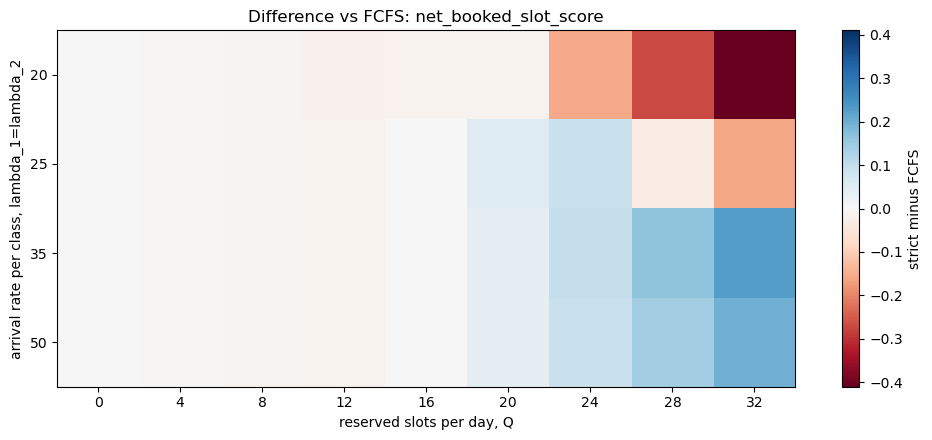

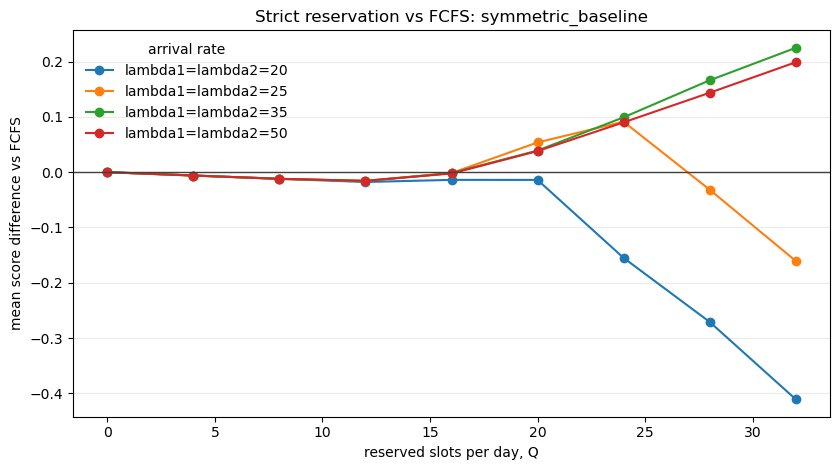

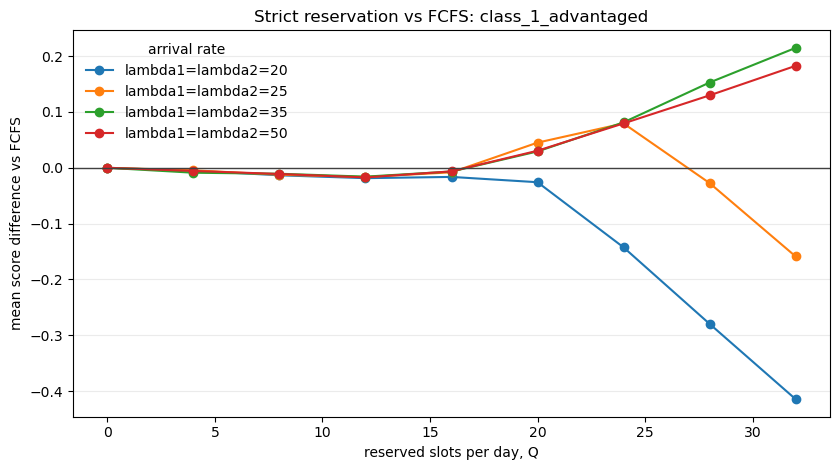

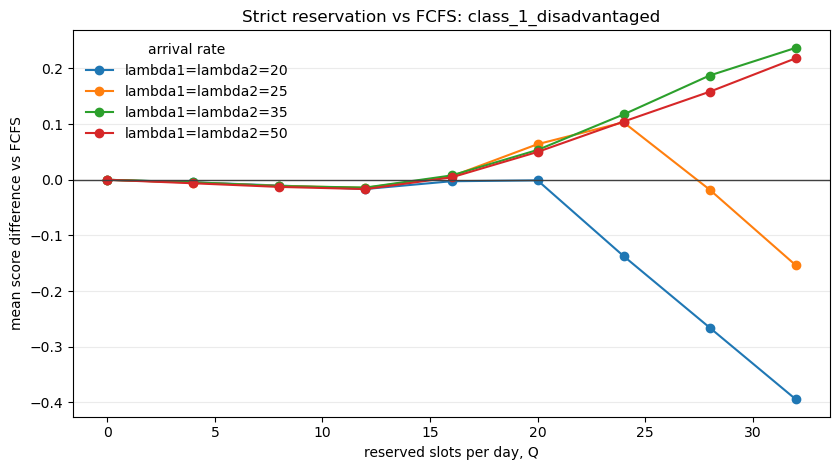

In [12]:
def plot_delta_heatmap(
    summary: pd.DataFrame,
    *,
    score_name: str,
    scenario_type: str = "symmetric_baseline",
    class_1_weight: float = MAIN_CLASS_1_WEIGHT,
    slot_cost: float = MAIN_SLOT_COST,
    wait_penalty: float = MAIN_NET_WAIT_PENALTY,
) -> None:
    subset = summary[
        (summary["score_name"] == score_name)
        & (summary["scenario_type"] == scenario_type)
        & (summary["class_1_weight"] == class_1_weight)
        & (summary["slot_cost"] == slot_cost)
        & (summary["wait_penalty"] == wait_penalty)
    ]
    pivot = subset.pivot(index="class_arrival_rate", columns="Q", values="mean").sort_index()
    if pivot.empty or np.isnan(pivot.values).all():
        print("No rows for the selected heatmap filters.")
        return

    fig, ax = plt.subplots(figsize=(10, 4.5))
    limit = np.nanmax(abs(pivot.values))
    image = ax.imshow(pivot.values, aspect="auto", cmap="RdBu", vmin=-limit, vmax=limit)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([int(value) for value in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([int(value) for value in pivot.index])
    ax.set_xlabel("reserved slots per day, Q")
    ax.set_ylabel("arrival rate per class, lambda_1=lambda_2")
    ax.set_title(f"Difference vs FCFS: {score_name}")
    fig.colorbar(image, ax=ax, label="strict minus FCFS")
    fig.tight_layout()


def plot_equal_arrival_rate_curves(
    summary: pd.DataFrame,
    *,
    score_name: str,
    scenario_type: str,
    class_1_weight: float = MAIN_CLASS_1_WEIGHT,
    slot_cost: float = MAIN_SLOT_COST,
    wait_penalty: float = MAIN_NET_WAIT_PENALTY,
) -> None:
    subset = summary[
        (summary["score_name"] == score_name)
        & (summary["scenario_type"] == scenario_type)
        & (summary["class_1_weight"] == class_1_weight)
        & (summary["slot_cost"] == slot_cost)
        & (summary["wait_penalty"] == wait_penalty)
    ]
    if subset.empty:
        print(f"No rows for {scenario_type}.")
        return

    fig, ax = plt.subplots(figsize=(8.5, 4.8))
    for class_arrival_rate, group in subset.groupby("class_arrival_rate"):
        group = group.sort_values("Q")
        ax.plot(
            group["Q"],
            group["mean"],
            marker="o",
            label=f"lambda1=lambda2={class_arrival_rate:g}",
        )

    ax.axhline(0, color="0.25", linewidth=1)
    ax.set_title(f"Strict reservation vs FCFS: {scenario_type}")
    ax.set_xlabel("reserved slots per day, Q")
    ax.set_ylabel("mean score difference vs FCFS")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False, title="arrival rate")
    fig.tight_layout()


plot_delta_heatmap(difference_summary, score_name="net_booked_slot_score")
for scenario_type in SCENARIO_TYPES:
    plot_equal_arrival_rate_curves(
        difference_summary,
        score_name="net_booked_slot_score",
        scenario_type=scenario_type,
    )


## Win Region Map

This plot summarizes where strict reservation wins, possibly wins, or loses after choosing the best `Q` for each behavior case and equal class arrival rate.


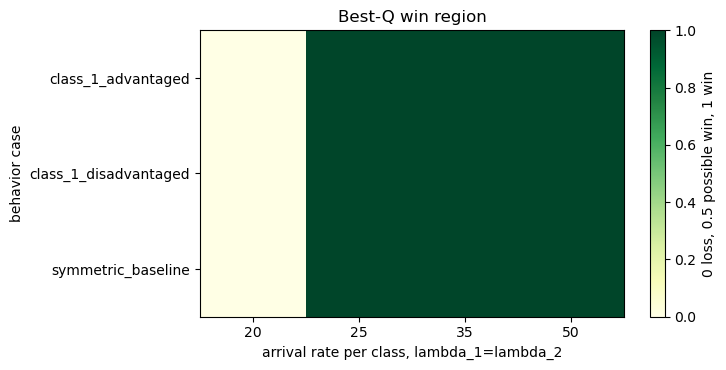

In [13]:
classification_score = {"loss": 0.0, "possible_win": 0.5, "win": 1.0}

win_region = difference_summary[
    (difference_summary["score_name"] == "net_booked_slot_score")
    & (difference_summary["class_1_weight"] == MAIN_CLASS_1_WEIGHT)
    & (difference_summary["slot_cost"] == MAIN_SLOT_COST)
    & (difference_summary["wait_penalty"] == MAIN_NET_WAIT_PENALTY)
].copy()
win_region["classification_score"] = win_region["classification"].map(classification_score)
best_region = (
    win_region.sort_values(["classification_score", "mean"], ascending=False)
    .groupby(["scenario_type", "class_arrival_rate"], as_index=False)
    .head(1)
)

if best_region.empty:
    print("No rows for the selected win-region filters.")
else:
    pivot = best_region.pivot(index="scenario_type", columns="class_arrival_rate", values="classification_score").sort_index()
    fig, ax = plt.subplots(figsize=(7.5, 3.8))
    image = ax.imshow(pivot.values, aspect="auto", cmap="YlGn", vmin=0, vmax=1)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([int(value) for value in pivot.columns])
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("arrival rate per class, lambda_1=lambda_2")
    ax.set_ylabel("behavior case")
    ax.set_title("Best-Q win region")
    fig.colorbar(image, ax=ax, label="0 loss, 0.5 possible win, 1 win")
    fig.tight_layout()


## Best Q Curves

This plot shows how the best number of protected slots changes as the equal arrival rate changes.


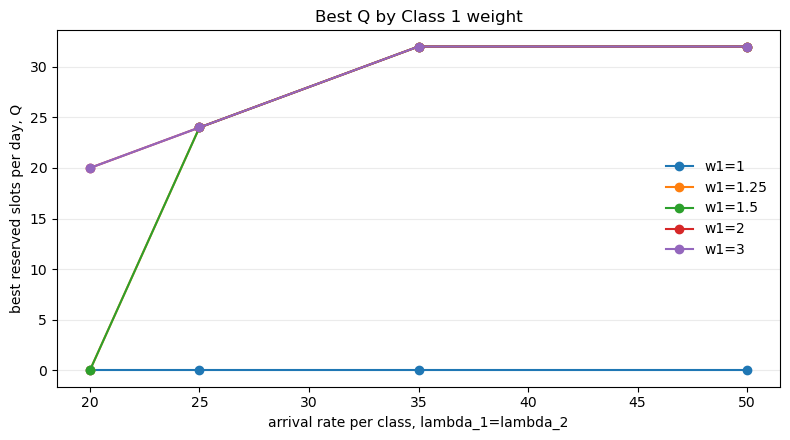

In [14]:
best_q_curves = best_q[
    (best_q["score_name"] == "net_booked_slot_score")
    & (best_q["scenario_type"] == "symmetric_baseline")
    & (best_q["slot_cost"] == MAIN_SLOT_COST)
    & (best_q["wait_penalty"] == MAIN_NET_WAIT_PENALTY)
]

if best_q_curves.empty:
    print("No rows for the selected best-Q filters.")
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for weight, group in best_q_curves.groupby("class_1_weight"):
        group = group.sort_values("class_arrival_rate")
        ax.plot(group["class_arrival_rate"], group["Q"], marker="o", label=f"w1={weight:g}")

    ax.set_title("Best Q by Class 1 weight")
    ax.set_xlabel("arrival rate per class, lambda_1=lambda_2")
    ax.set_ylabel("best reserved slots per day, Q")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()


## Slot-Cost Sensitivity

This plot shows how the answer changes at the baseline equal arrival rate when protected slots are treated as more or less costly.


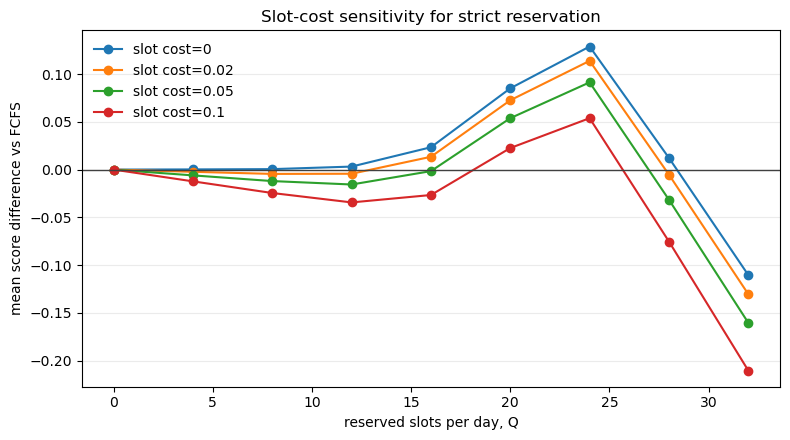

In [15]:
sensitivity = difference_summary[
    (difference_summary["score_name"] == "net_booked_slot_score")
    & (difference_summary["scenario_type"] == "symmetric_baseline")
    & (difference_summary["class_arrival_rate"] == BASELINE_CLASS_ARRIVAL_RATE)
    & (difference_summary["class_1_weight"] == MAIN_CLASS_1_WEIGHT)
    & (difference_summary["wait_penalty"] == MAIN_NET_WAIT_PENALTY)
]

if sensitivity.empty:
    print("No rows for the selected slot-cost sensitivity filters.")
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    for slot_cost, group in sensitivity.groupby("slot_cost"):
        group = group.sort_values("Q")
        ax.plot(group["Q"], group["mean"], marker="o", label=f"slot cost={slot_cost:g}")

    ax.axhline(0, color="0.25", linewidth=1)
    ax.set_title("Slot-cost sensitivity for strict reservation")
    ax.set_xlabel("reserved slots per day, Q")
    ax.set_ylabel("mean score difference vs FCFS")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False)
    fig.tight_layout()
